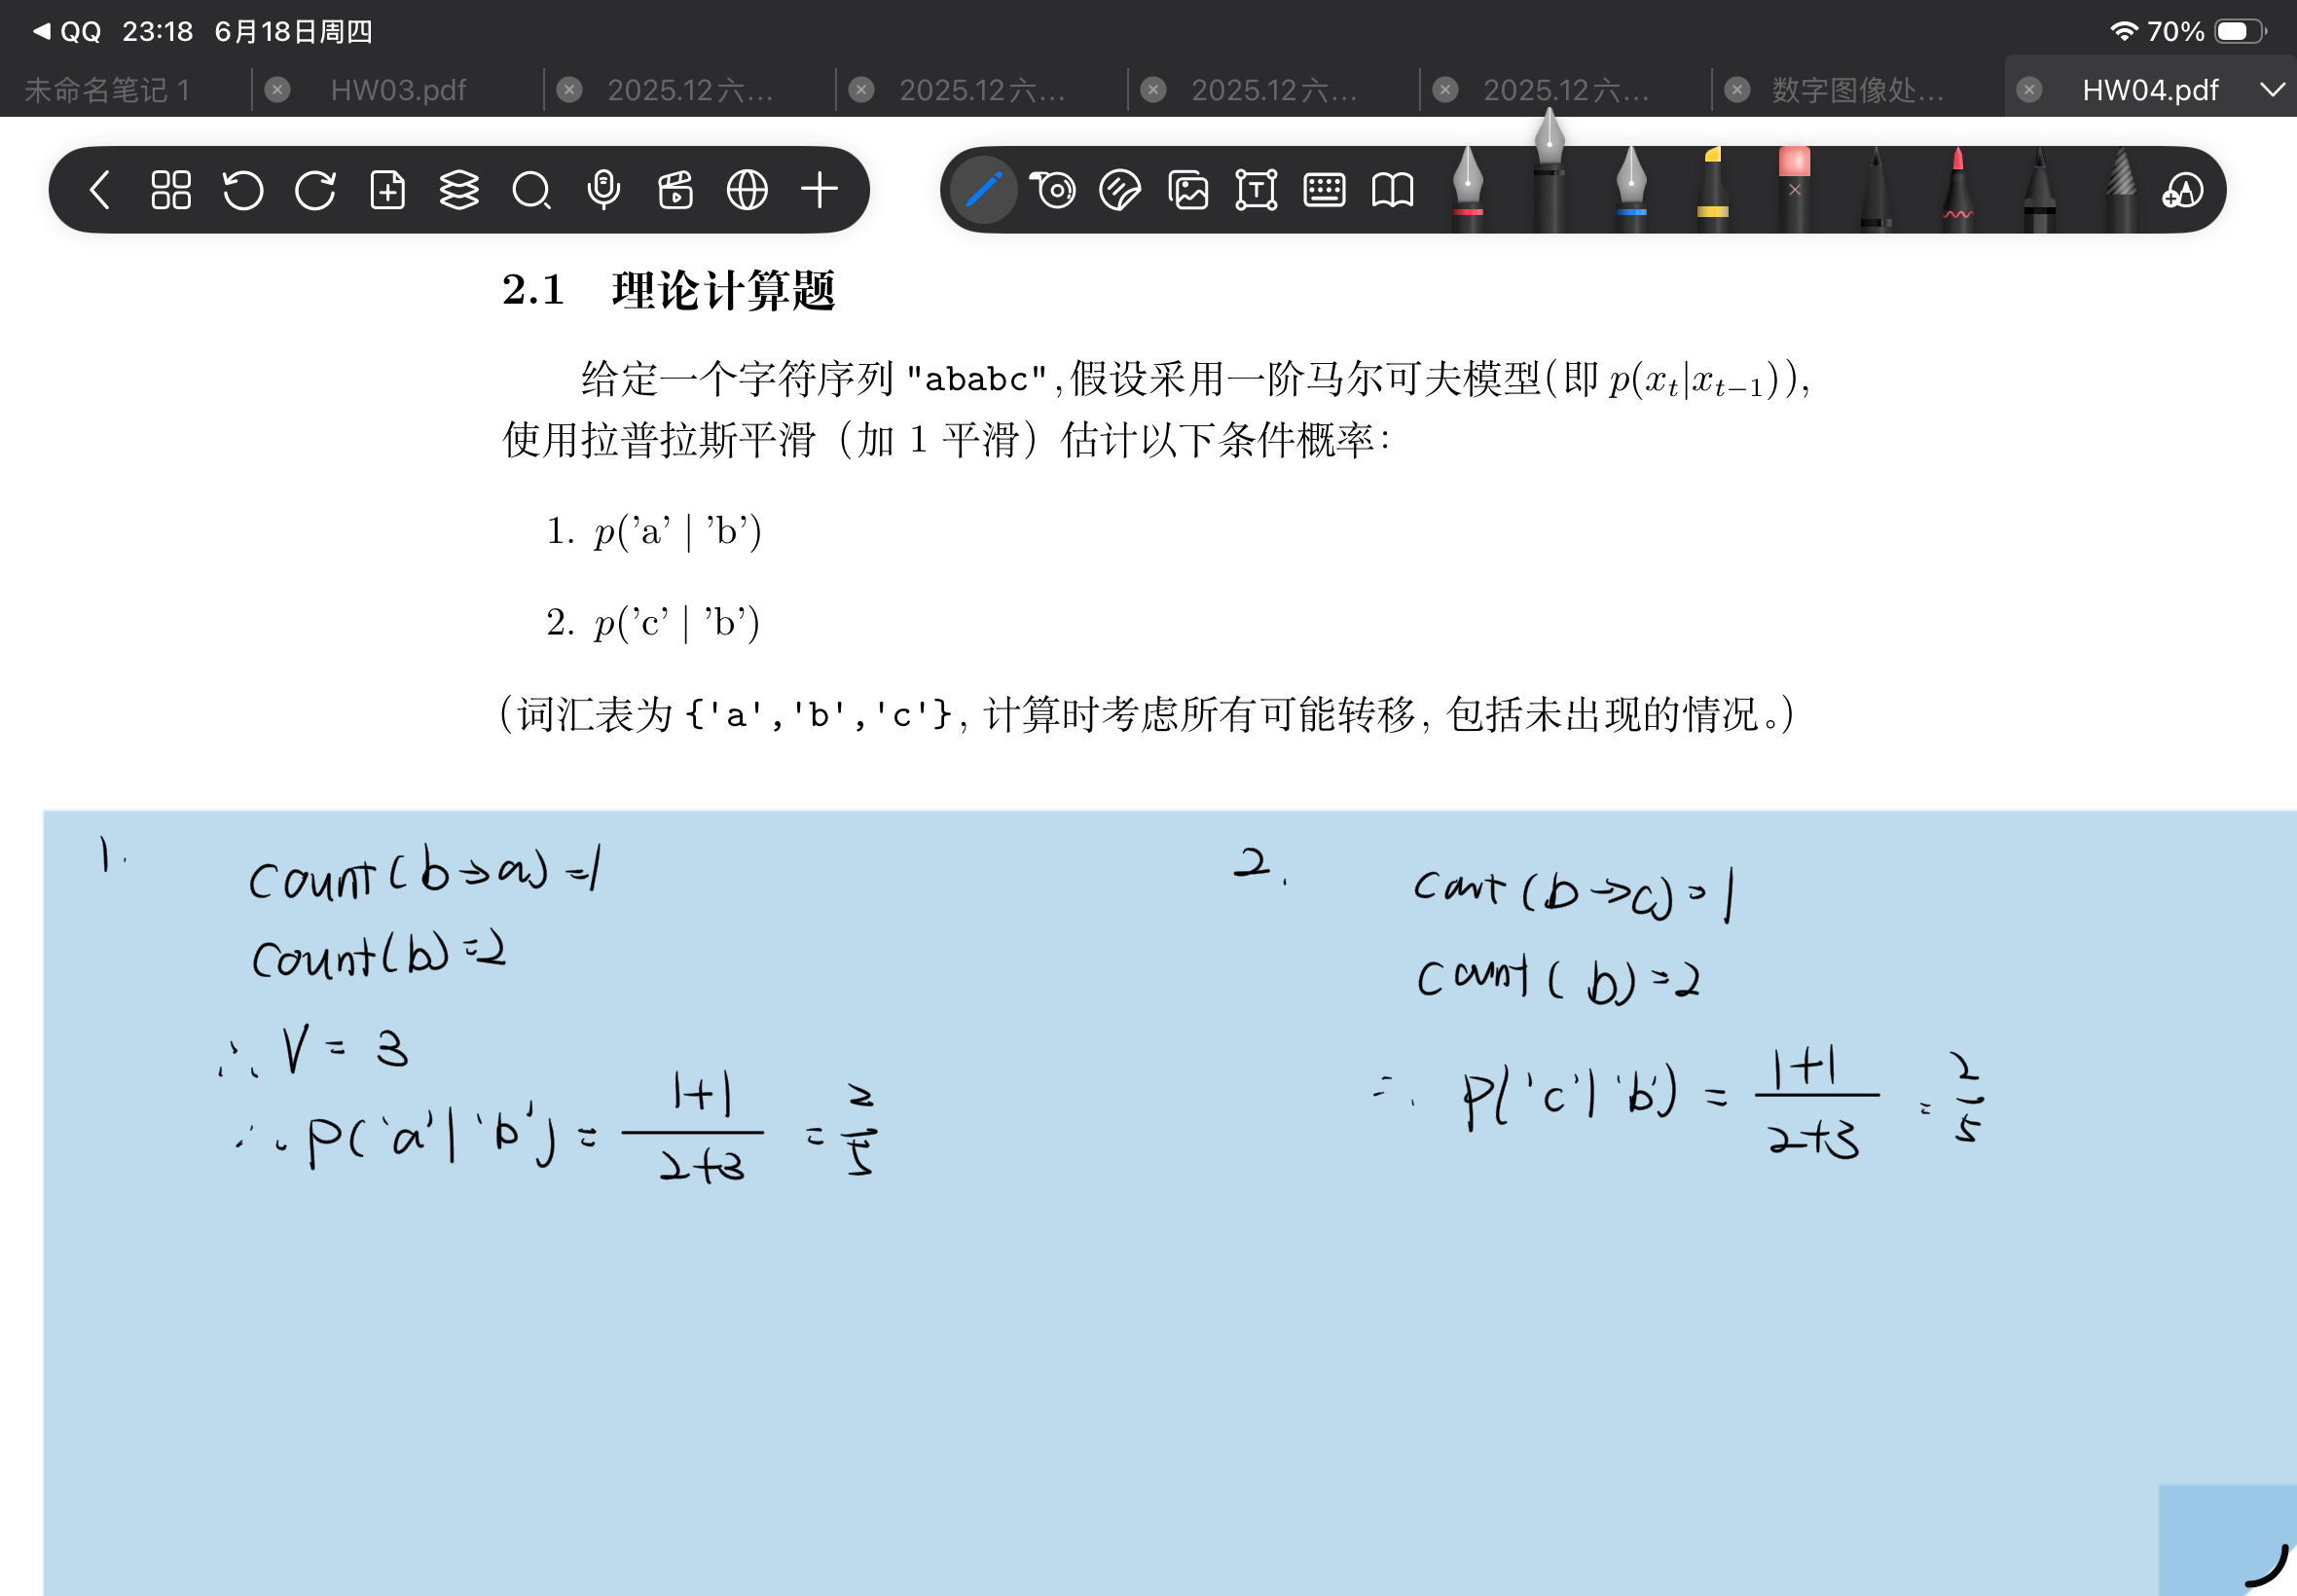

>  2.2 编程题

In [1]:
import re
from collections import Counter

def preprocess_text(text, n):
    """
    对文本进行预处理，构建词汇表，并生成自回归语言模型的滑动窗口样本。
    
    参数:
        text (str): 输入文本
        n (int): 滑动窗口长度（特征词数）
    
    返回:
        vocab (dict): 词汇表，键为单词，值为整数ID（按频率降序分配，从0开始）
        (features, labels): features为列表，每个元素是长度为n的词列表；
                            labels为列表，每个元素是对应的下一个词（字符串）
    """
    # 参数合法性校验
    if not isinstance(n, int) or n <= 0:
        raise ValueError("滑动窗口长度n必须是正整数")
    
    # 1. 转换为小写，去除标点符号（只保留字母和空格）
    cleaned = re.sub(r'[^a-zA-Z\s]', '', text).lower()
    
    # 2. 按空格分词
    words = cleaned.split()
    if len(words) < n:
        # 单词总数不足窗口长度，无法生成任何样本
        vocab = {}
        if words:
            freq = Counter(words)
            sorted_words = sorted(freq.items(), key=lambda x: (-x[1], x[0]))
            vocab = {word: idx for idx, (word, _) in enumerate(sorted_words)}
        return vocab, ([], [])
    
    # 3. 构建词汇表（按出现频率降序排序，分配整数ID从0开始）
    freq = Counter(words)
    # 频率降序，同频按单词字典序保证结果稳定
    sorted_words = sorted(freq.items(), key=lambda x: (-x[1], x[0]))
    vocab = {word: idx for idx, (word, _) in enumerate(sorted_words)}
    
    # 4. 滑动窗口：只有存在下一个词才保留样本
   
    
    
    # 替换滑动窗口部分代码
    features = []
    labels = []
# 遍历所有能取到长度n窗口的起始位置
    for i in range(len(words) - n + 1):
        feature_win = words[i:i+n]
        features.append(feature_win)
    # 判断是否存在下一个词
        if i + n < len(words):
            label = words[i + n]
        else:
            label = None
        labels.append(label)
    return vocab, (features, labels)    
# 测试
if __name__ == "__main__":
    txt = "The time machine"
    v, (f, l) = preprocess_text(txt, 2)
    print("vocab:", v)
    print("features:", f)
    print("labels:", l)

vocab: {'machine': 0, 'the': 1, 'time': 2}
features: [['the', 'time'], ['time', 'machine']]
labels: ['machine', None]


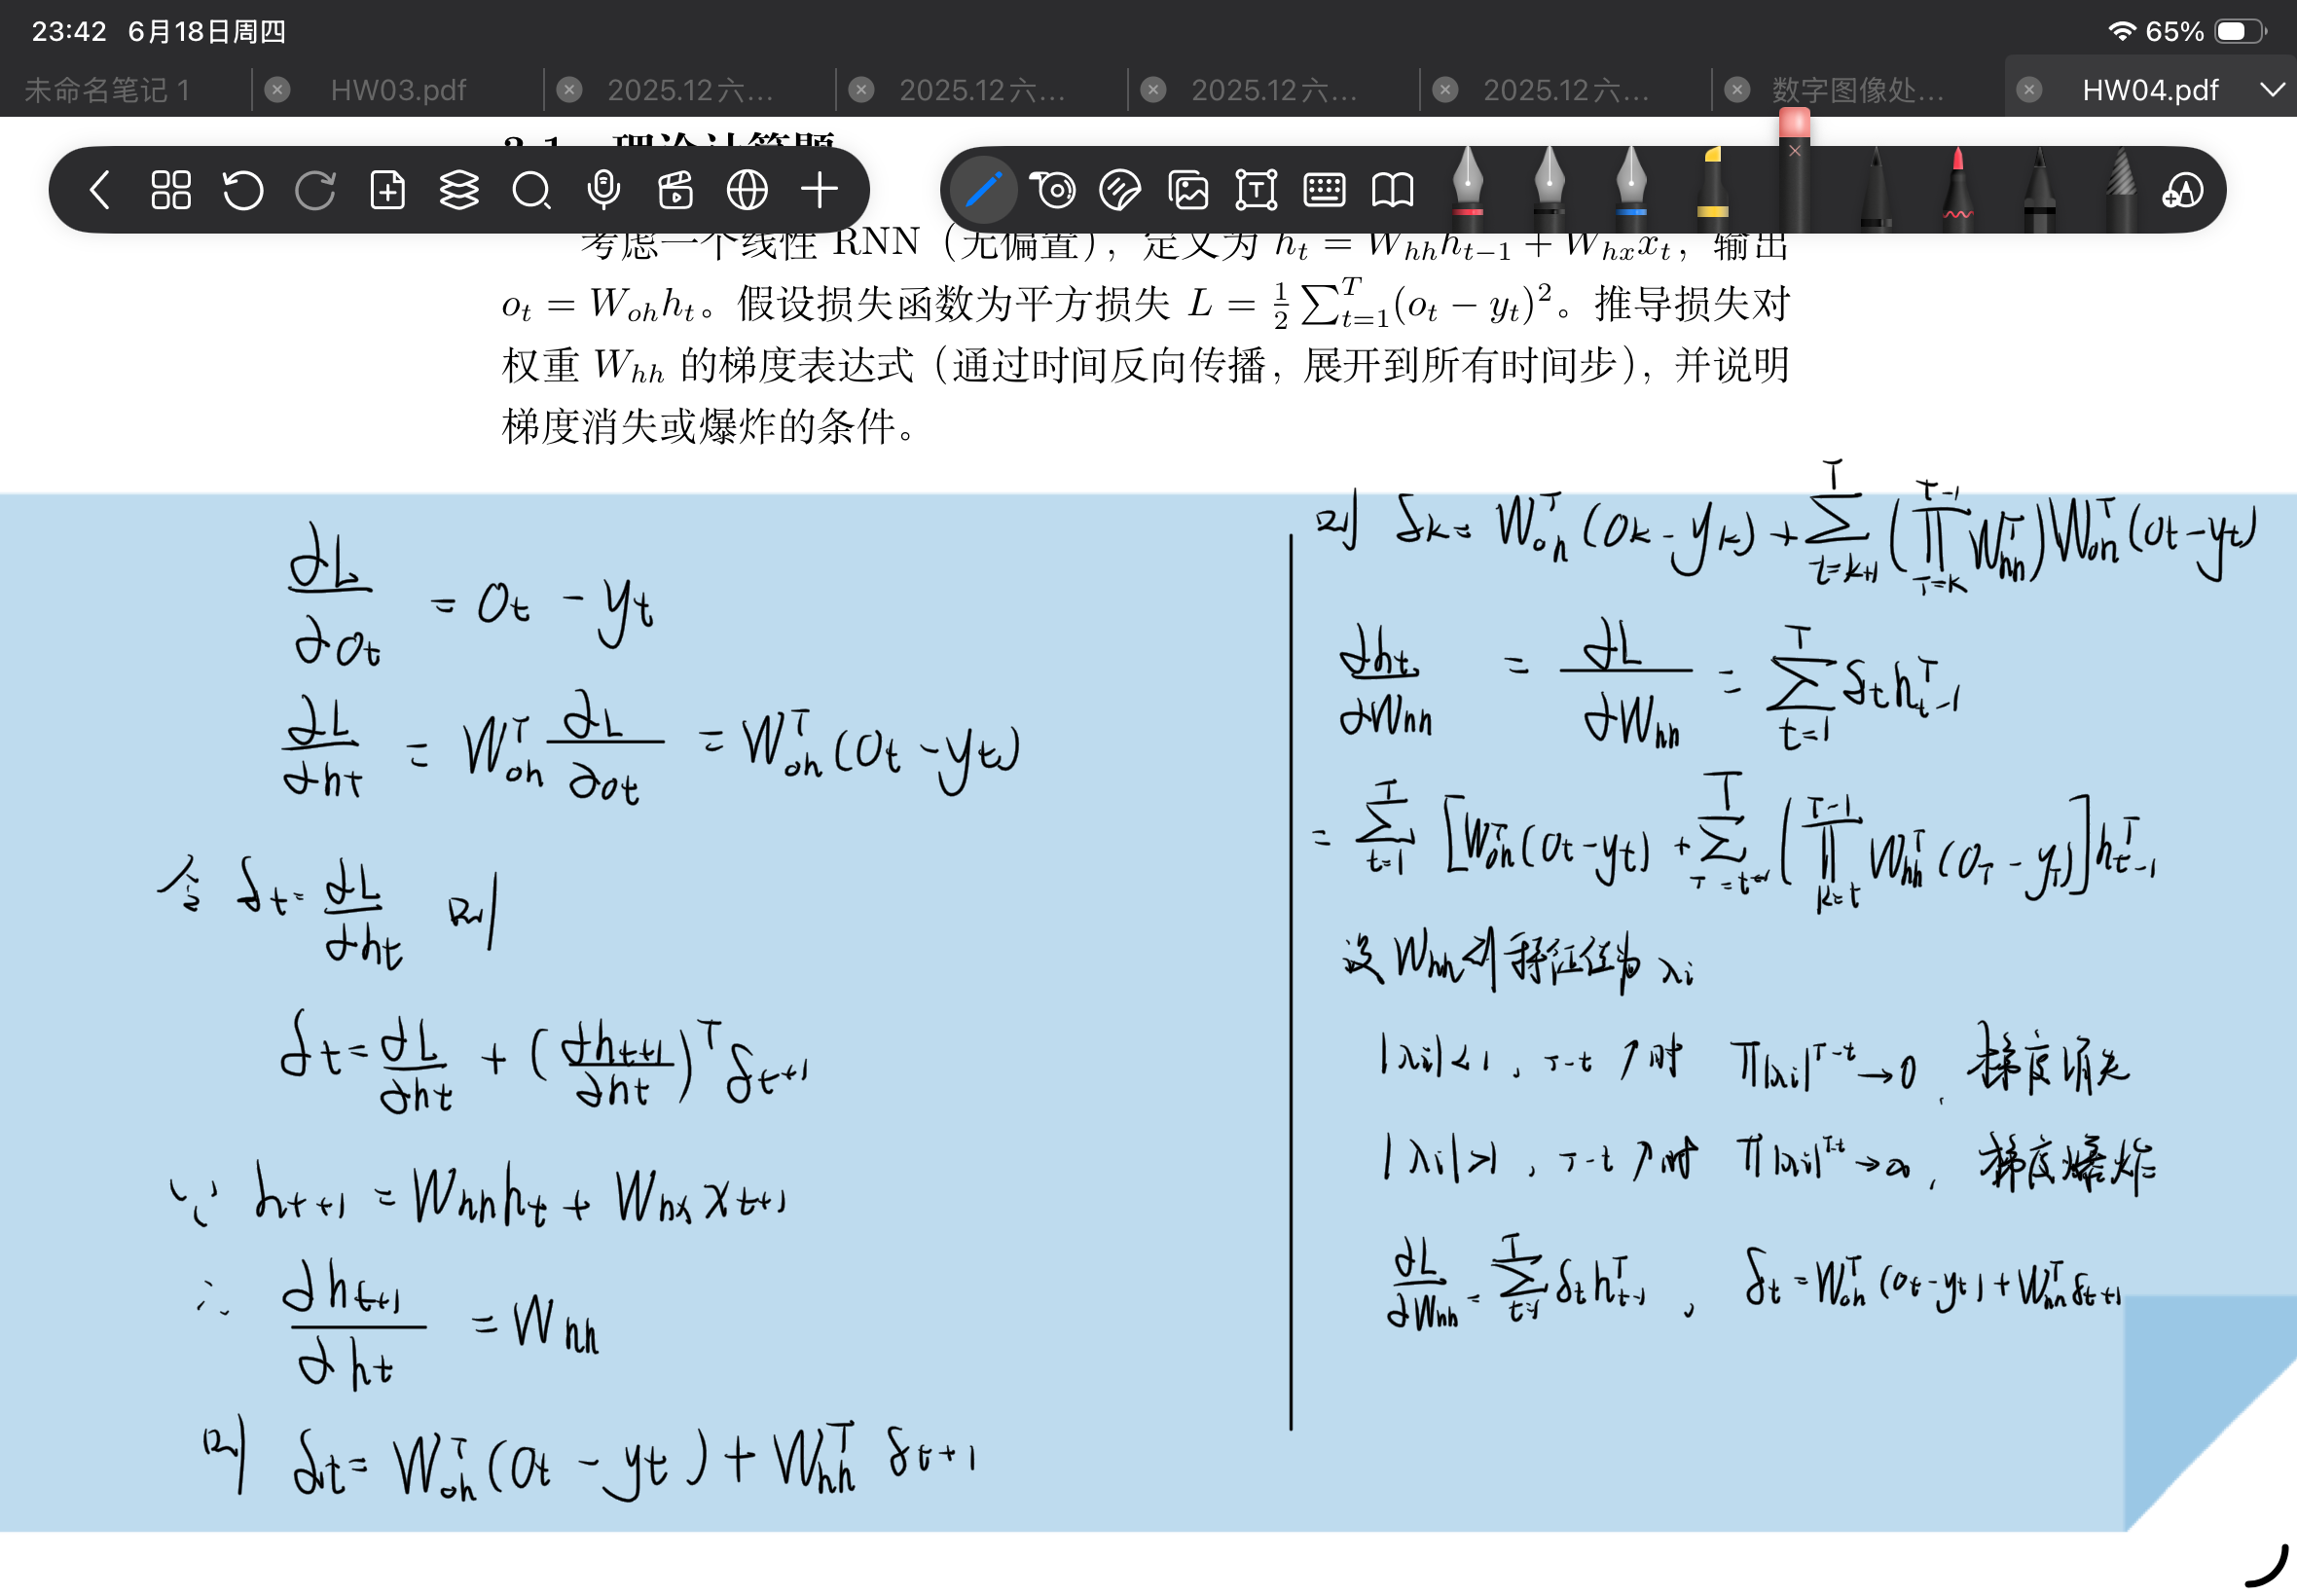

> 3.2 编程题

In [2]:
import numpy as np

def rnn_forward(x_t, h_prev, W_hx, W_hh, b_h):
    """
    RNN 单元前向传播。

    参数:
        x_t   : (batch_size, input_size)
        h_prev: (batch_size, hidden_size)
        W_hx  : (input_size, hidden_size)
        W_hh  : (hidden_size, hidden_size)
        b_h   : (hidden_size,)

    返回:
        h_t   : (batch_size, hidden_size)
        cache : 用于反向传播的中间值 (x_t, h_prev, W_hx, W_hh, b_h, a)
    """
    a = x_t @ W_hx + h_prev @ W_hh + b_h   # (batch, hidden)
    h_t = np.tanh(a)
    cache = (x_t, h_prev, W_hx, W_hh, b_h, a)
    return h_t, cache

def rnn_backward(dh_next, cache):
    """
    RNN 单元单步反向传播（计算梯度，不更新参数）。

    参数:
        dh_next: 损失对 h_t 的梯度，形状 (batch_size, hidden_size)
        cache  : 前向传播保存的中间值 (x_t, h_prev, W_hx, W_hh, b_h, a)

    返回:
        dx_t    : 损失对 x_t 的梯度，形状 (batch_size, input_size)
        dh_prev : 损失对 h_prev 的梯度，形状 (batch_size, hidden_size)
        dW_hx   : 损失对 W_hx 的梯度，形状 (input_size, hidden_size)
        dW_hh   : 损失对 W_hh 的梯度，形状 (hidden_size, hidden_size)
        db_h    : 损失对 b_h 的梯度，形状 (hidden_size,)
    """
    x_t, h_prev, W_hx, W_hh, b_h, a = cache
    batch_size = x_t.shape[0]

    # tanh 的导数: dtanh = 1 - tanh^2
    dtanh = 1 - np.tanh(a)**2          # (batch, hidden)
    # 上游梯度乘以 tanh 的导数
    da = dh_next * dtanh               # (batch, hidden)

    # 计算各参数的梯度
    db_h = np.sum(da, axis=0)          # (hidden,)
    dW_hh = h_prev.T @ da              # (hidden, hidden)
    dW_hx = x_t.T @ da                 # (input, hidden)

    dh_prev = da @ W_hh.T              # (batch, hidden)
    dx_t = da @ W_hx.T                 # (batch, input)

    return dx_t, dh_prev, dW_hx, dW_hh, db_h

In [3]:
batch_size, input_size, hidden_size = 4, 10, 20
x_t = np.random.randn(batch_size, input_size)
h_prev = np.random.randn(batch_size, hidden_size)
W_hx = np.random.randn(input_size, hidden_size)
W_hh = np.random.randn(hidden_size, hidden_size)
b_h = np.random.randn(hidden_size)

h_t, cache = rnn_forward(x_t, h_prev, W_hx, W_hh, b_h)
dh_next = np.random.randn(batch_size, hidden_size)
dx, dh_prev, dW_hx, dW_hh, db = rnn_backward(dh_next, cache)

print("dx shape:", dx.shape)        # (4,10)
print("dh_prev shape:", dh_prev.shape) # (4,20)
print("dW_hx shape:", dW_hx.shape)  # (10,20)
print("dW_hh shape:", dW_hh.shape)  # (20,20)
print("db shape:", db.shape)        # (20,)

dx shape: (4, 10)
dh_prev shape: (4, 20)
dW_hx shape: (10, 20)
dW_hh shape: (20, 20)
db shape: (20,)


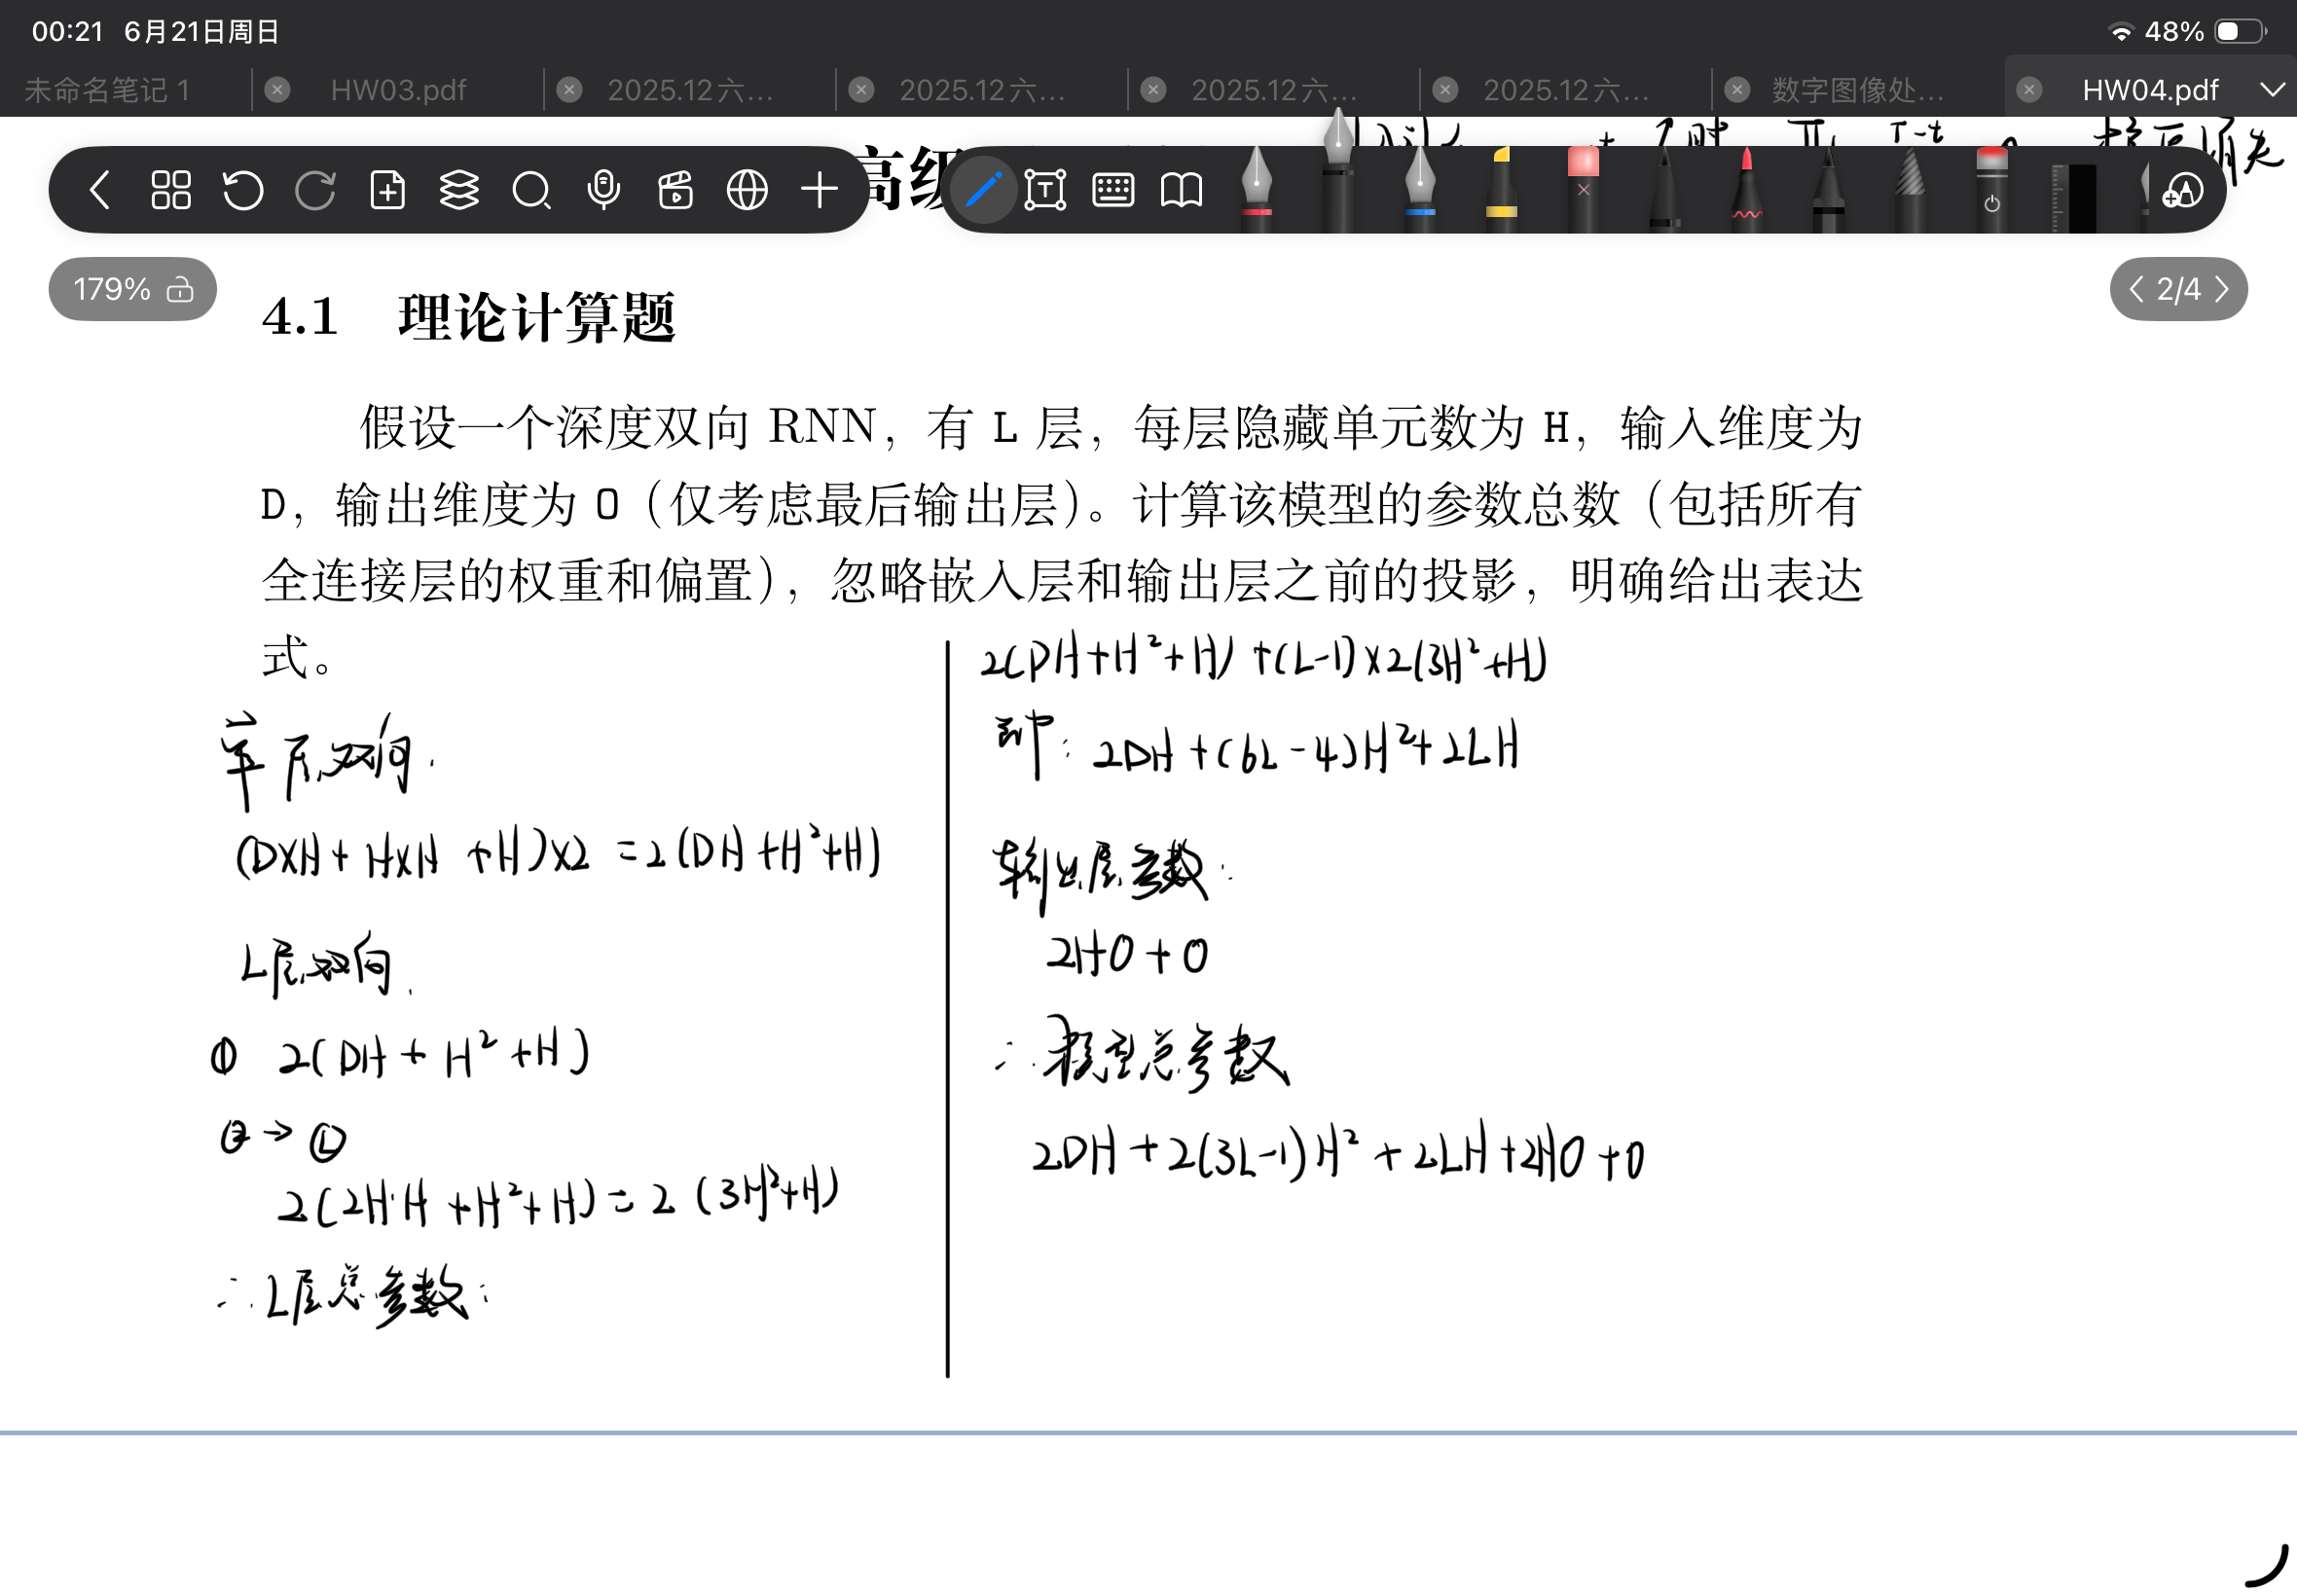

> 4.2 编程题

In [4]:
import torch
import torch.nn as nn

def bidirectional_rnn_encoder(X, hidden_dim, num_layers=1):
    seq_len, batch_size, input_dim = X.shape

    # 创建双向 RNN 层（batch_first=False，保持输入为 (seq, batch, feature)）
    rnn = nn.RNN(
        input_size=input_dim,
        hidden_size=hidden_dim,
        num_layers=num_layers,
        bidirectional=True,
        batch_first=False
    )

    # 前向传播，返回 output 和最终隐藏状态 h_n
    # output 形状: (seq_len, batch, num_directions * hidden_dim)
    # 对于双向，num_directions=2，output 的最后维度直接拼接了前向和后向
    outputs, _ = rnn(X)  # 忽略 h_n，因为我们需要的是每个时间步的输出

    # outputs[-1] 即为最后一个时间步的拼接隐藏状态
    final_state = outputs[-1]  # 形状 (batch, 2 * hidden_dim)

    return outputs, final_state

In [5]:
seq_len, batch, input_dim = 10, 4, 16
hidden_dim = 32
X = torch.randn(seq_len, batch, input_dim)
outputs, final_state = bidirectional_rnn_encoder(X, hidden_dim)
print(outputs.shape)      # torch.Size([10, 4, 64])
print(final_state.shape)  # torch.Size([4, 64])

torch.Size([10, 4, 64])
torch.Size([4, 64])


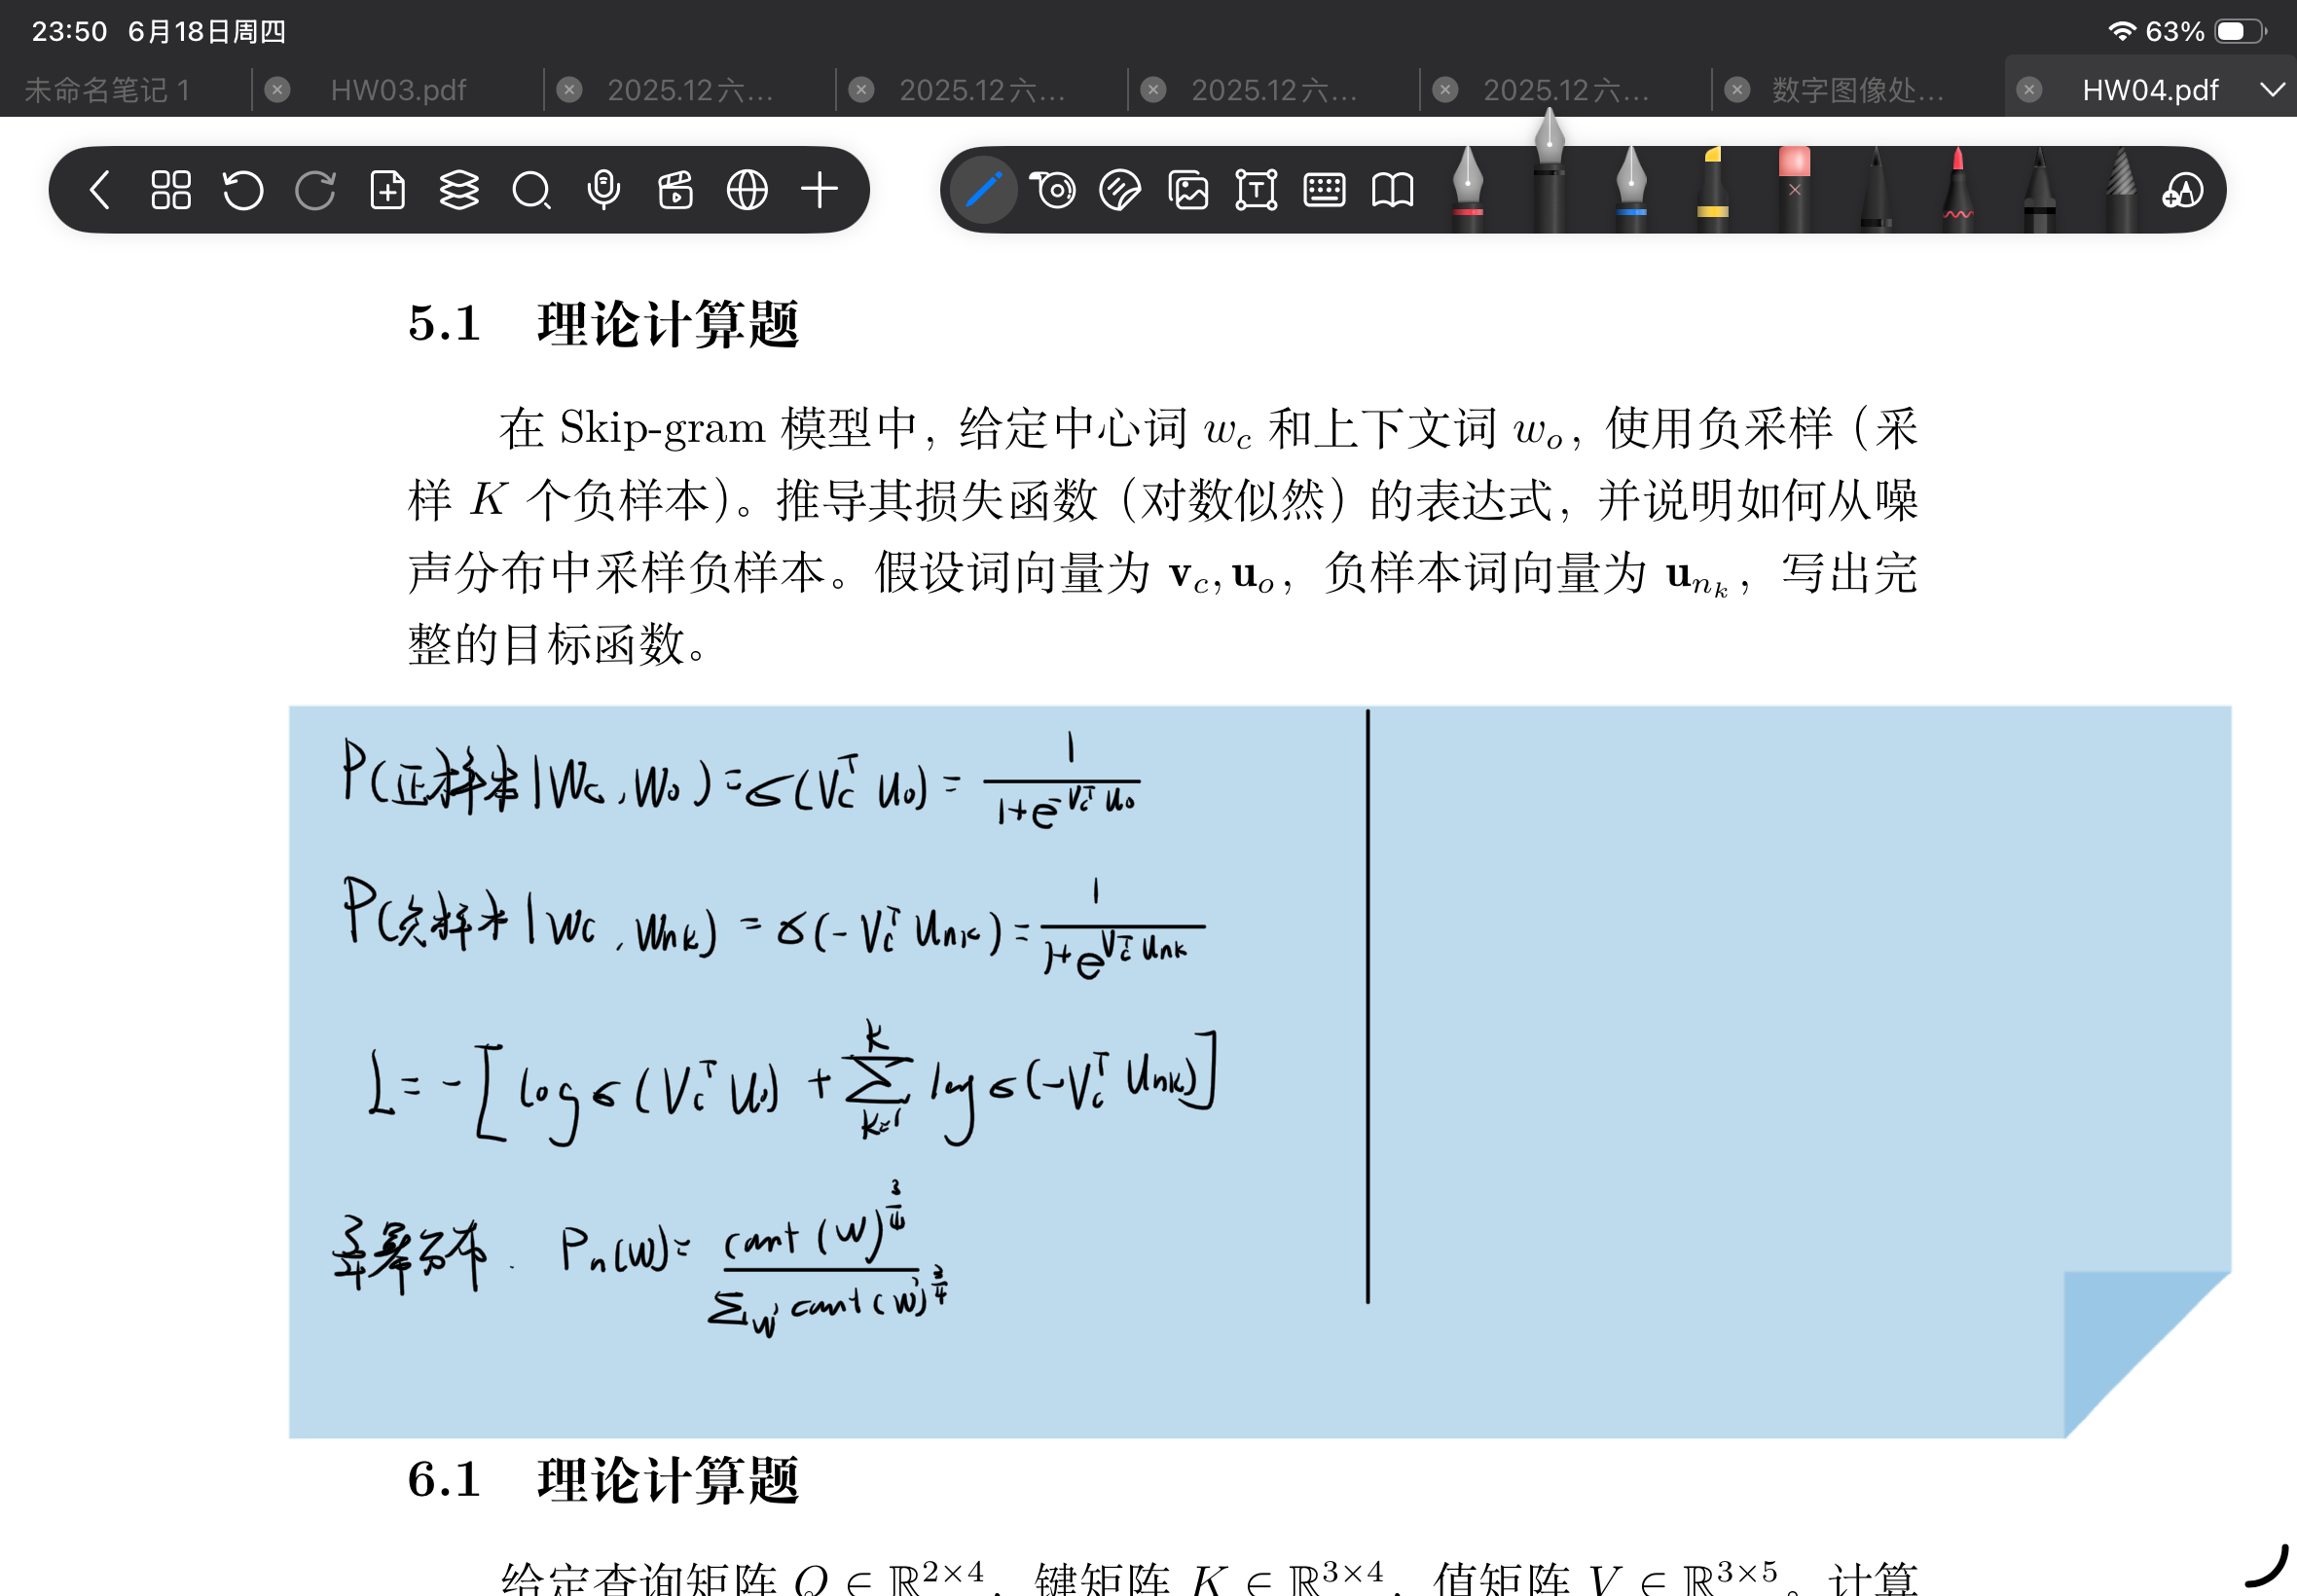

> 5.2 编程题

In [6]:
import torch
import torch.nn.functional as F

def cbow_forward(context_indices, center_indices, W, W_out):
    """
    CBOW 前向传播和损失计算（完整 softmax）。

    参数:
        context_indices : 上下文词索引，形状 (batch_size, context_size)
        center_indices  : 中心词索引，形状 (batch_size,)
        W               : 输入嵌入矩阵，形状 (V, d)
        W_out           : 输出权重矩阵，形状 (d, V)

    返回:
        loss : 标量张量，交叉熵损失（平均 batch）
    """
    batch_size, context_size = context_indices.shape
    V, d = W.shape

    # 1. 获取上下文词的嵌入向量 (batch, context_size, d)
    embeds = W[context_indices]  # (batch, context_size, d)

    # 2. 计算平均上下文向量 (batch, d)
    h = embeds.mean(dim=1)  # (batch, d)

    # 3. 计算 logits (batch, V)
    logits = h @ W_out  # (batch, V)

    # 4. 计算交叉熵损失
    # 使用 PyTorch 的 cross_entropy，它内部先做 log_softmax 再取负
    loss = F.cross_entropy(logits, center_indices, reduction='mean')
    return loss

In [7]:
V, d = 1000, 128
batch_size, context_size = 4, 5
context = torch.randint(0, V, (batch_size, context_size))
center = torch.randint(0, V, (batch_size,))
W = torch.randn(V, d, requires_grad=True)
W_out = torch.randn(d, V, requires_grad=True)

loss = cbow_forward(context, center, W, W_out)
print(loss.item())  # 输出损失值
loss.backward()     # 计算梯度


15.285665512084961


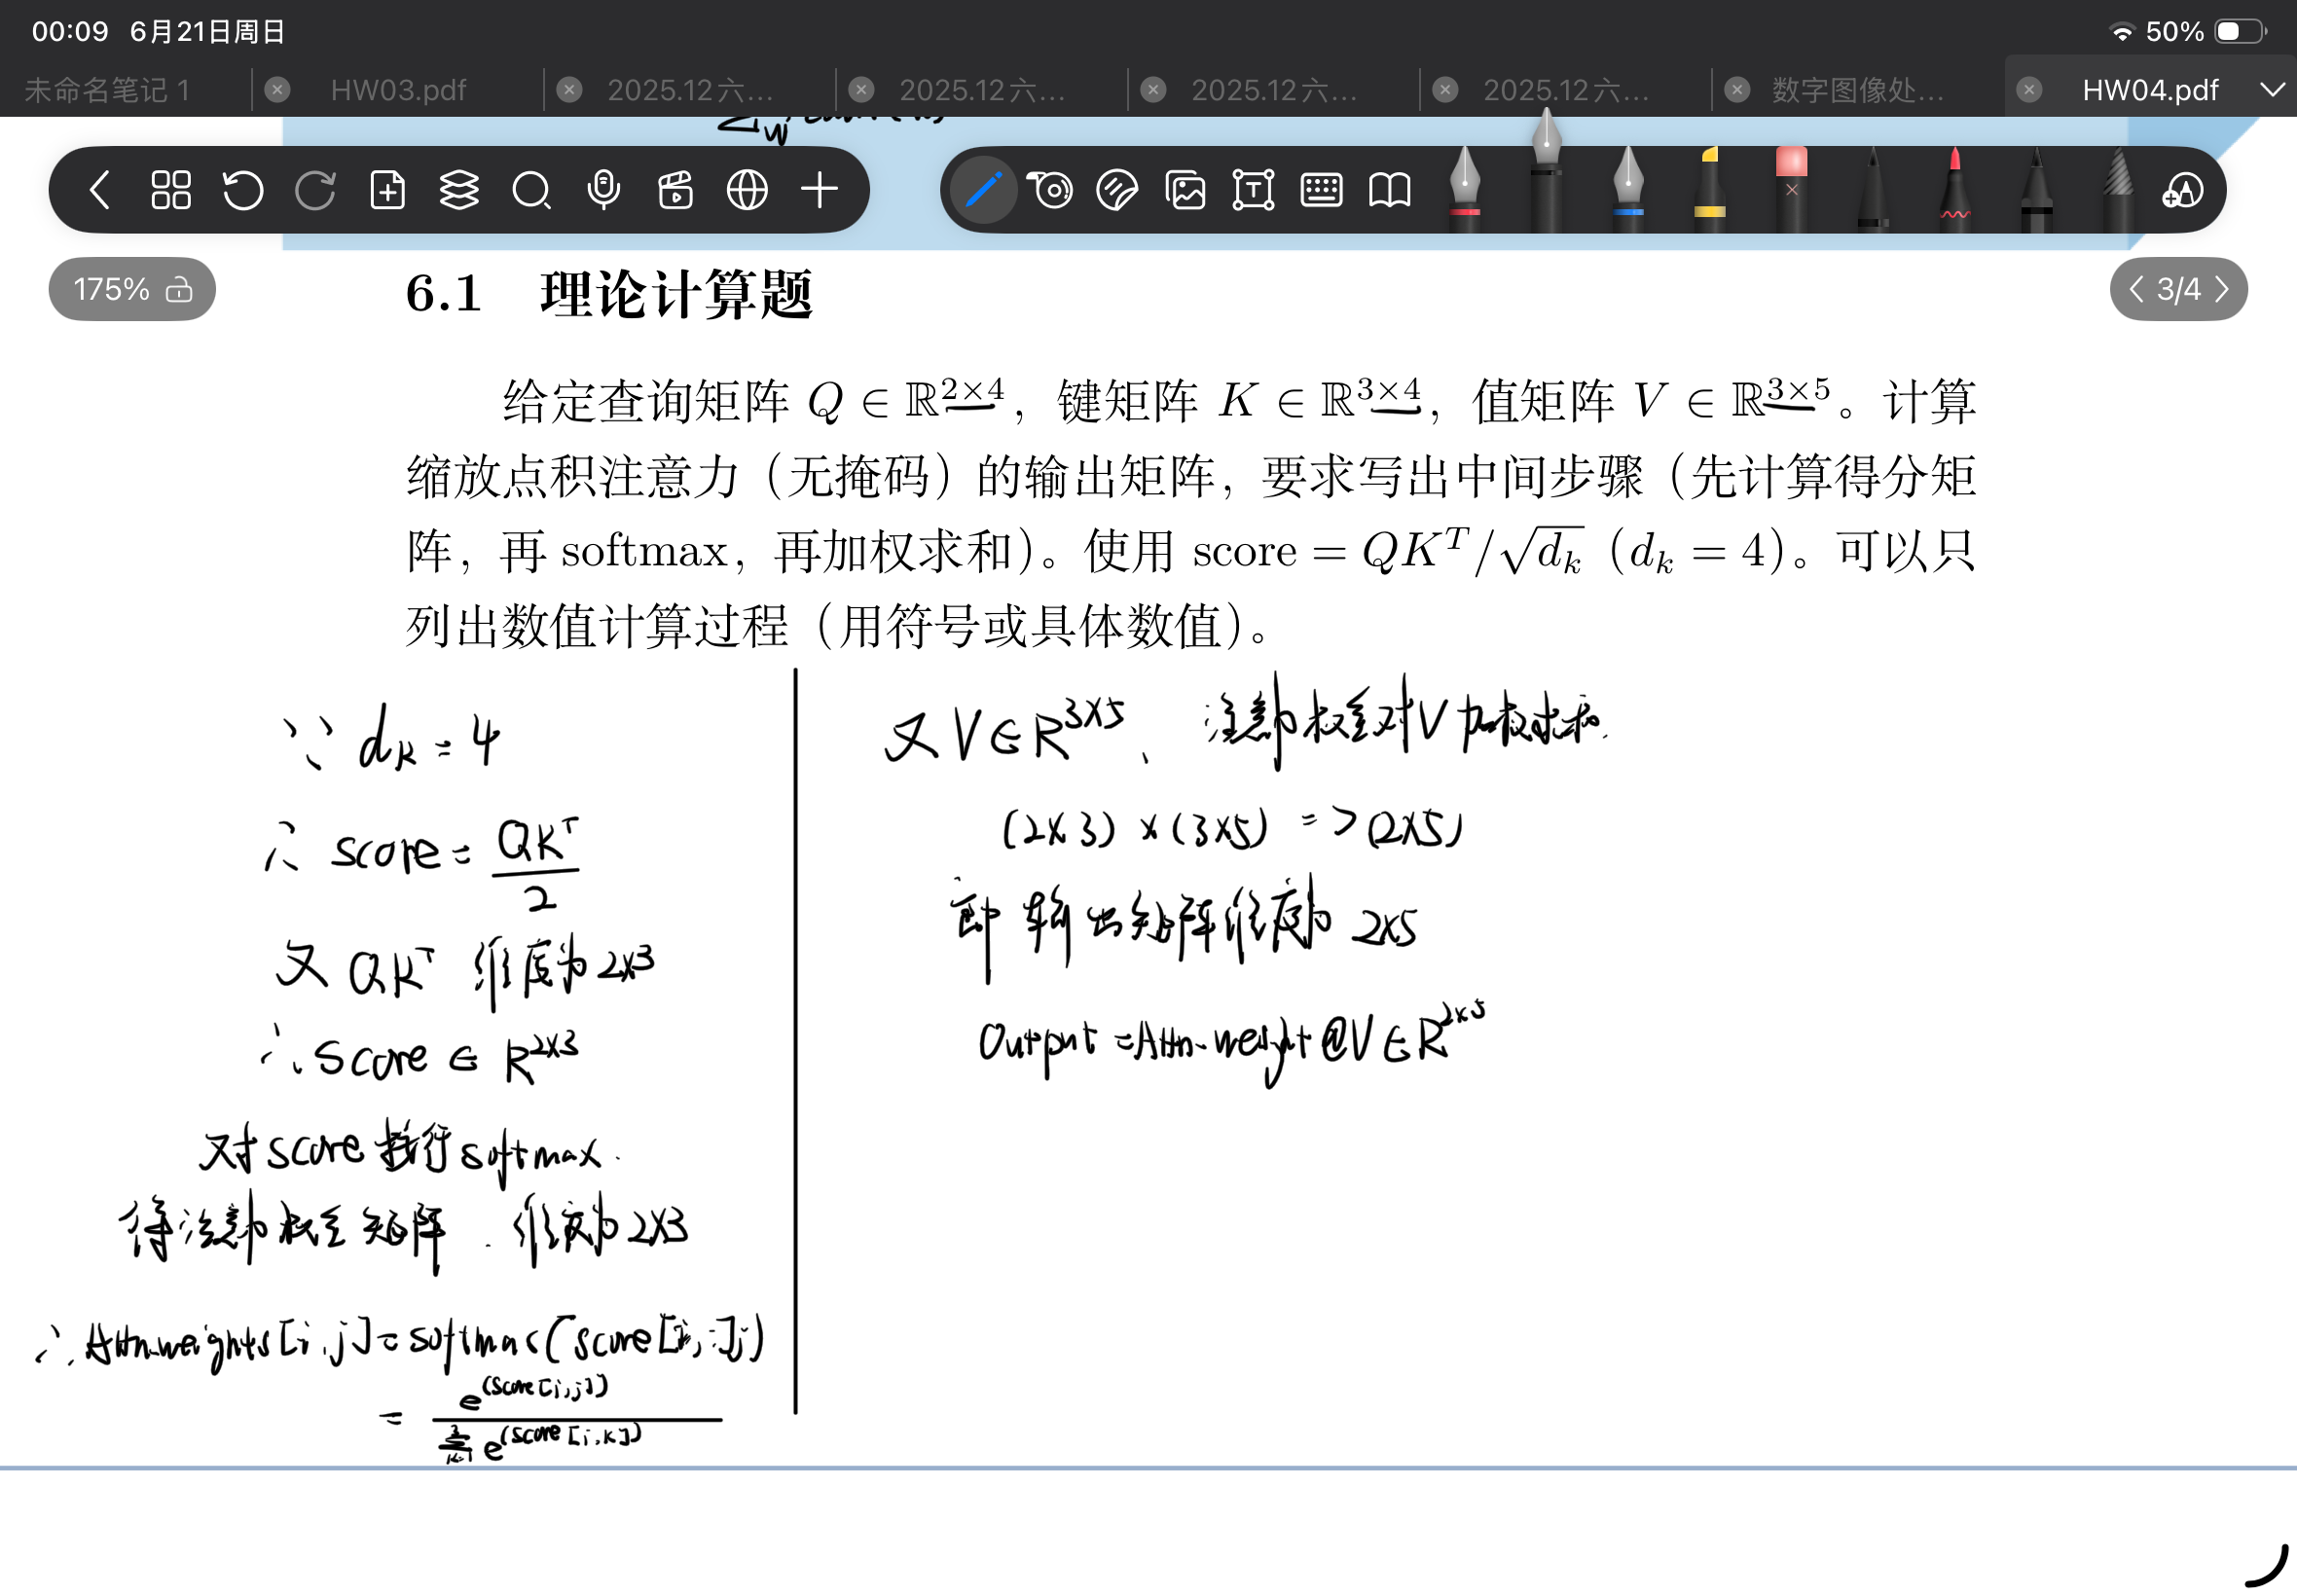

> 6.2 编程题

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=4, num_heads=2):
        """
        多头注意力模块（仅前向传播，无 mask）
        参数:
            d_model : 模型维度，此处固定为 4
            num_heads: 注意力头数，此处固定为 2
        """
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads   # 每个头的维度，此处为 2
        self.d_v = d_model // num_heads   # 与 d_k 相同

        # 线性投影层（无偏置）
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X):
        """
        输入:
            X : 形状 (seq_len, batch, d_model)
        输出:
            output : 形状 (seq_len, batch, d_model)
        """
        seq_len, batch, _ = X.size()

        # 1. 线性投影
        Q = self.W_q(X)  # (seq_len, batch, d_model)
        K = self.W_k(X)
        V = self.W_v(X)

        # 2. 分割为多个头并调整维度 (batch, num_heads, seq_len, d_k/v)
        Q = Q.view(seq_len, batch, self.num_heads, self.d_k).transpose(0, 1).transpose(1, 2)
        K = K.view(seq_len, batch, self.num_heads, self.d_k).transpose(0, 1).transpose(1, 2)
        V = V.view(seq_len, batch, self.num_heads, self.d_v).transpose(0, 1).transpose(1, 2)

        # 3. 缩放点积注意力
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)  # (batch, num_heads, seq_len, seq_len)
        attn_weights = F.softmax(scores, dim=-1)                          # 注意力权重
        attn_output = torch.matmul(attn_weights, V)                       # (batch, num_heads, seq_len, d_v)

        # 4. 拼接所有头并恢复形状 (seq_len, batch, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(seq_len, batch, self.d_model)

        # 5. 最终线性层
        output = self.W_o(attn_output)  # (seq_len, batch, d_model)

        return output

In [9]:
#  (seq_len=5, batch=4, d_model=4)
seq_len, batch, d_model = 5, 4, 4
X = torch.randn(seq_len, batch, d_model)


model = MultiHeadAttention(d_model=4, num_heads=2)
output = model(X)

print(output.shape)  # torch.Size([5, 4, 4])

torch.Size([5, 4, 4])
